# Control de Calidad Predictivo — Caso MetalX

**Predicción de piezas defectuosas por lote en un proceso de inyección de plástico**

Universidad Peruana de Ciencias Aplicadas · Ingeniería Industrial

---

## Contexto del problema

MetalX opera una línea de **inyección de plástico**. Cada lote producido sale con
una cantidad variable de piezas defectuosas, y detectarlas *después* de producir
implica desperdicio de material y de tiempo de máquina.

La pregunta del negocio es directa:

> ¿Se puede anticipar el número de defectos de un lote a partir de los sensores
> de la máquina, antes de terminar de producirlo?

## Planteamiento

| | |
|---|---|
| **Tipo de problema** | Regresión supervisada |
| **Variable objetivo** | `Defectos_Lote` — piezas defectuosas por lote |
| **Predictores** | 4 variables de proceso medidas en tiempo real |
| **Observaciones** | 2 500 lotes |
| **Modelos a comparar** | Árbol de Decisión · Random Forest · Red Neuronal |
| **Validación** | Hold-out 80/20 + validación cruzada de 5 pliegues |

## 1. Configuración e importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, GridSearchCV, cross_val_score, KFold,
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import keras
from keras.models import Sequential
from keras.layers import Dense, Input

# Semilla global: garantiza que este notebook devuelva los mismos resultados
# en cada ejecución, incluida la red neuronal.
SEED = 42
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Carga y exploración inicial del dataset

El archivo `df_metalx.csv` usa **punto y coma** como separador.

In [2]:
datos = pd.read_csv("df_metalx.csv", sep=";")

print(f"Dimensiones: {datos.shape[0]} filas x {datos.shape[1]} columnas\n")
datos.head()

Dimensiones: 2500 filas x 5 columnas



,Temp_Matriz_C,Presion_Inyeccion_Bar,Tiempo_Ciclo_s,Vibracion_RMS,Defectos_Lote
0,202.5000,169.7000,10.7600,4.2100,29.1100
1,237.0000,165.9000,11.3100,5.6600,63.9400
2,223.9000,154.4000,13.9800,2.1300,18.8200
3,215.9000,177.4000,10.3800,2.1500,14.4900
4,189.4000,132.0000,14.0900,4.2800,39.7500


In [3]:
datos.describe()

,Temp_Matriz_C,Presion_Inyeccion_Bar,Tiempo_Ciclo_s,Vibracion_RMS,Defectos_Lote
count,"2,500.0000","2,500.0000","2,500.0000","2,500.0000","2,500.0000"
mean,209.9326,149.6869,11.4555,3.9467,39.3604
std,17.4530,17.3061,2.0141,1.4177,28.8305
min,180.1000,120.0000,8.0000,1.5000,0.0000
25%,194.5000,134.8000,9.7100,2.7575,21.2300
50%,210.4000,149.6000,11.4000,3.9350,34.8800
75%,225.0000,164.6250,13.1900,5.1400,52.9425
max,240.0000,180.0000,15.0000,6.5000,533.3100


### Diccionario de variables

| Variable | Descripción | Unidad |
|---|---|---|
| `Temp_Matriz_C` | Temperatura de la matriz de inyección | °C |
| `Presion_Inyeccion_Bar` | Presión de inyección | Bar |
| `Tiempo_Ciclo_s` | Duración del ciclo de producción | segundos |
| `Vibracion_RMS` | Vibración RMS de la máquina | — |
| **`Defectos_Lote`** | **Variable objetivo:** piezas defectuosas del lote | unidades |

## 3. Auditoría de calidad de datos

Antes de modelar se verifica la integridad del dataset: valores nulos y
registros duplicados.

In [4]:
auditoria = pd.DataFrame({
    "nulos": datos.isnull().sum(),
    "% nulos": (datos.isnull().sum() / len(datos) * 100).round(2),
    "tipo": datos.dtypes.astype(str),
})
print(auditoria, "\n")
print(f"Registros duplicados: {datos.duplicated().sum()}")

                       nulos  % nulos     tipo
Temp_Matriz_C              0   0.0000  float64
Presion_Inyeccion_Bar      0   0.0000  float64
Tiempo_Ciclo_s             0   0.0000  float64
Vibracion_RMS              0   0.0000  float64
Defectos_Lote              0   0.0000  float64 

Registros duplicados: 0


> **Resultado:** el dataset no presenta valores nulos ni duplicados. A diferencia
> del proyecto de rutas logísticas, aquí no hace falta una fase de saneamiento,
> lo que permite concentrar el esfuerzo en el modelado.

## 4. Distribución de la variable objetivo

El comportamiento de `Defectos_Lote` condiciona qué tan bien puede funcionar
cualquier modelo, así que conviene caracterizarlo antes de entrenar.

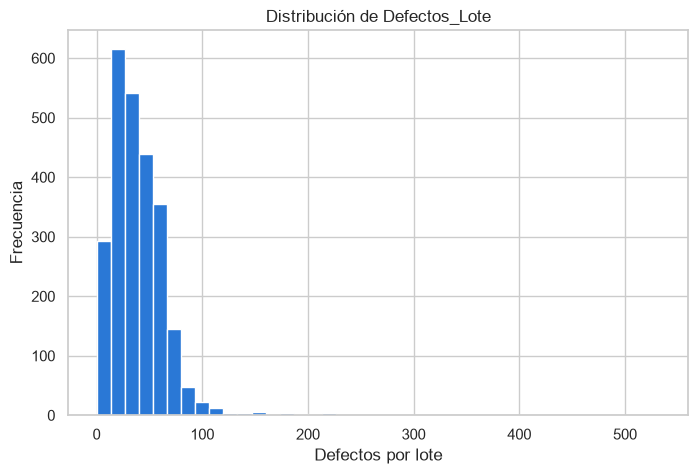

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(datos["Defectos_Lote"], bins=40, color="#2a78d6", edgecolor="white")
plt.title("Distribución de Defectos_Lote")
plt.xlabel("Defectos por lote")
plt.ylabel("Frecuencia")
plt.show()

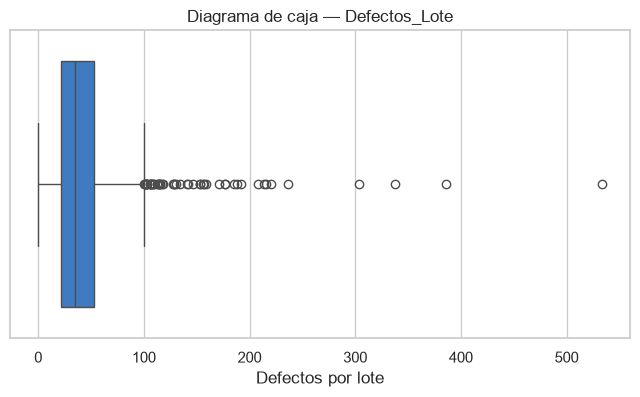

Asimetría (skewness): 4.6531
Mediana:              34.88
Máximo:               533.31


In [6]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=datos["Defectos_Lote"], color="#2a78d6")
plt.title("Diagrama de caja — Defectos_Lote")
plt.xlabel("Defectos por lote")
plt.show()

print(f"Asimetría (skewness): {datos['Defectos_Lote'].skew():.4f}")
print(f"Mediana:              {datos['Defectos_Lote'].median():.2f}")
print(f"Máximo:               {datos['Defectos_Lote'].max():.2f}")

> **Interpretación.** La variable objetivo es **fuertemente asimétrica a la
> derecha** (*skewness* ≈ 4.65): la mediana está en torno a 35 defectos, pero el
> máximo llega a 533. Existe una **cola larga de lotes catastróficos**, poco
> frecuentes pero muy costosos.
>
> Esto es la advertencia más importante del proyecto: el error cuadrático (MSE)
> castiga desproporcionadamente esos casos extremos, así que hay que esperar un
> **techo bajo en el R²** por más que el modelo capture bien el comportamiento
> típico.

## 5. Análisis de correlación

¿Cuál de las cuatro variables de proceso se relaciona realmente con los defectos?

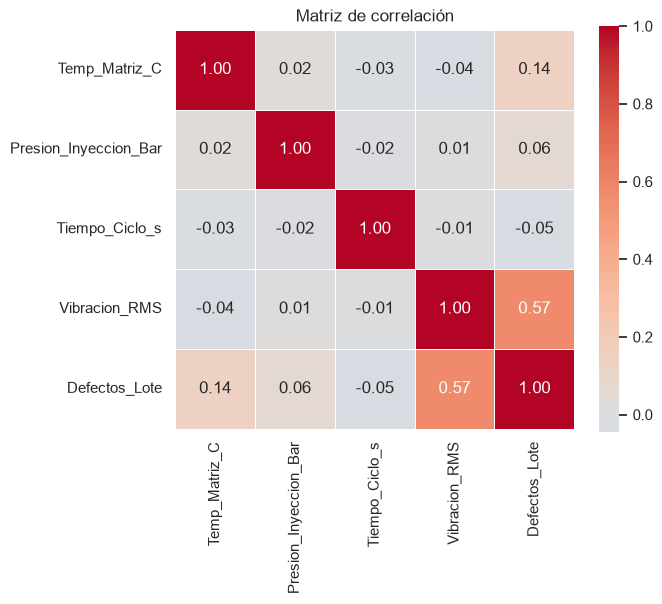

Correlación de cada variable con Defectos_Lote:
Vibracion_RMS            0.5746
Temp_Matriz_C            0.1416
Presion_Inyeccion_Bar    0.0630
Tiempo_Ciclo_s          -0.0459
Name: Defectos_Lote, dtype: float64


In [7]:
plt.figure(figsize=(7, 6))
sns.heatmap(datos.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

print("Correlación de cada variable con Defectos_Lote:")
print(datos.corr()["Defectos_Lote"].drop("Defectos_Lote")
      .sort_values(ascending=False))

> **Hallazgo clave.** De las cuatro variables de proceso, **solo la vibración RMS
> muestra una relación apreciable** con los defectos (ρ ≈ 0.57). La temperatura
> de matriz apenas alcanza 0.14, y presión y tiempo de ciclo son prácticamente
> irrelevantes.
>
> Traducido a planta: **la vibración de la máquina es la señal a vigilar.**

## 6. Preparación de los datos

Partición 80/20 y escalado. El escalado es necesario para la red neuronal;
los modelos basados en árboles son invariantes a la escala, así que se entrenan
con las variables originales.

In [8]:
X = datos[["Temp_Matriz_C", "Presion_Inyeccion_Bar", "Tiempo_Ciclo_s", "Vibracion_RMS"]]
y = datos["Defectos_Lote"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Entrenamiento: {X_train.shape[0]} lotes")
print(f"Prueba:        {X_test.shape[0]} lotes")

Entrenamiento: 2000 lotes
Prueba:        500 lotes


In [9]:
def evaluar(nombre, y_real, y_pred):
    # Calcula las tres metricas de regresion y las devuelve como diccionario.
    metricas = {
        "Modelo": nombre,
        "MAE": mean_absolute_error(y_real, y_pred),
        "MSE": mean_squared_error(y_real, y_pred),
        "R2": r2_score(y_real, y_pred),
    }
    print(f"{nombre}")
    print(f"  MAE : {metricas['MAE']:.4f}")
    print(f"  MSE : {metricas['MSE']:.4f}")
    print(f"  R²  : {metricas['R2']:.4f}")
    return metricas

## 7. Modelo 1 — Árbol de Decisión

Se optimizan la profundidad máxima y el mínimo de muestras por división mediante
`GridSearchCV` con validación cruzada de 5 pliegues.

In [10]:
param_tree = {"max_depth": [3, 5], "min_samples_split": [2, 5, 10]}

grid_tree = GridSearchCV(DecisionTreeRegressor(random_state=SEED), param_tree, cv=5)
grid_tree.fit(X_train, y_train)

modelo_tree = grid_tree.best_estimator_
pred_tree = modelo_tree.predict(X_test)

print(f"Mejores parámetros: {grid_tree.best_params_}\n")
res_tree = evaluar("Árbol de Decisión", y_test, pred_tree)

Mejores parámetros: {'max_depth': 3, 'min_samples_split': 2}

Árbol de Decisión
  MAE : 10.8674
  MSE : 300.7367
  R²  : 0.4398


## 8. Modelo 2 — Random Forest

Un ensamble de 100 árboles. Además de las métricas, aporta la **importancia de
variables**, que es la parte más útil del proyecto para la toma de decisiones.

In [11]:
param_rf = {"n_estimators": [100], "max_depth": [3, 5], "min_samples_split": [2, 5, 10]}

grid_rf = GridSearchCV(RandomForestRegressor(random_state=SEED), param_rf, cv=5)
grid_rf.fit(X_train, y_train)

modelo_rf = grid_rf.best_estimator_
pred_rf = modelo_rf.predict(X_test)

print(f"Mejores parámetros: {grid_rf.best_params_}\n")
res_rf = evaluar("Random Forest", y_test, pred_rf)

Mejores parámetros: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}

Random Forest
  MAE : 10.1849
  MSE : 260.0292
  R²  : 0.5156


                variable  importancia  % del total
0          Vibracion_RMS       0.8928      89.3000
1          Temp_Matriz_C       0.0753       7.5000
2  Presion_Inyeccion_Bar       0.0239       2.4000
3         Tiempo_Ciclo_s       0.0080       0.8000


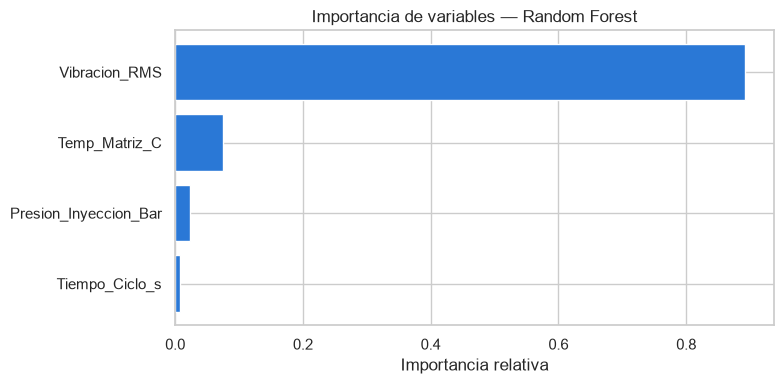

In [12]:
importancias = (pd.DataFrame({
    "variable": X.columns,
    "importancia": modelo_rf.feature_importances_,
}).sort_values("importancia", ascending=False).reset_index(drop=True))

importancias["% del total"] = (importancias["importancia"] * 100).round(1)
print(importancias)

plt.figure(figsize=(8, 4))
plt.barh(importancias["variable"][::-1], importancias["importancia"][::-1],
         color="#2a78d6")
plt.title("Importancia de variables — Random Forest")
plt.xlabel("Importancia relativa")
plt.tight_layout()
plt.show()

> **El resultado central del proyecto.** La **vibración RMS concentra cerca del
> 89 % de la importancia predictiva**, muy por encima de temperatura de matriz
> (≈ 7 %), presión de inyección (≈ 2 %) y tiempo de ciclo (≈ 1 %).
>
> **Implicación para la operación:** instrumentar y monitorear la vibración es la
> palanca de control de calidad más rentable de este proceso. Justifica priorizar
> el **mantenimiento predictivo de la máquina** por encima del ajuste fino de
> temperatura, presión o tiempo de ciclo — que es donde suele concentrarse el
> esfuerzo por intuición.

## 9. Modelo 3 — Red Neuronal (RNA)

Red densa de dos capas ocultas (16 → 8 → 1) con activación ReLU y salida lineal,
entrenada con Adam sobre las variables escaladas.

In [13]:
modelo_rna = Sequential([
    Input(shape=(X_train_sc.shape[1],)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1, activation="linear"),
])

modelo_rna.compile(optimizer="adam", loss="mse", metrics=["mae"])
modelo_rna.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = modelo_rna.fit(
    X_train_sc, y_train,
    epochs=100, batch_size=32,
    validation_split=0.2, verbose=0,
)

pred_rna = modelo_rna.predict(X_test_sc, verbose=0).flatten()
res_rna = evaluar("Red Neuronal (RNA)", y_test, pred_rna)

Red Neuronal (RNA)
  MAE : 9.7960
  MSE : 240.0543
  R²  : 0.5528


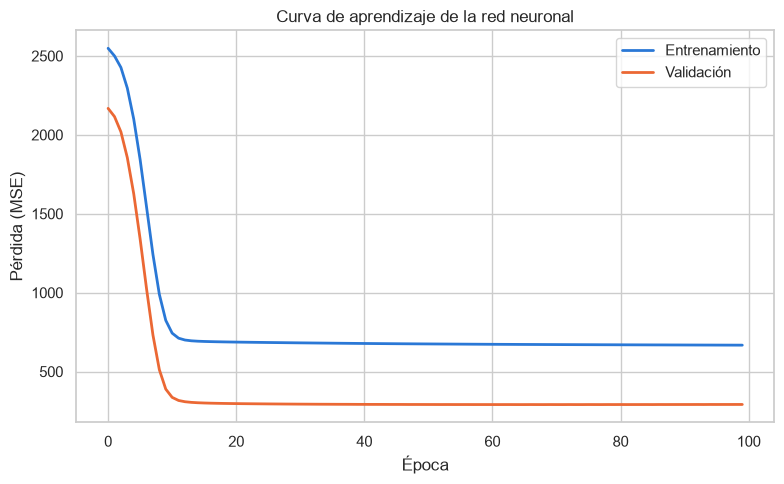

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Entrenamiento", color="#2a78d6", lw=2)
plt.plot(history.history["val_loss"], label="Validación", color="#eb6834", lw=2)
plt.title("Curva de aprendizaje de la red neuronal")
plt.xlabel("Época")
plt.ylabel("Pérdida (MSE)")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Validación cruzada (5 pliegues)

El hold-out de 500 lotes puede resultar optimista o pesimista por azar. La
validación cruzada reparte el riesgo entre 5 particiones distintas.

In [16]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

cv_tree = cross_val_score(modelo_tree, X_train, y_train, cv=kf,
                          scoring="neg_mean_squared_error")
cv_rf = cross_val_score(modelo_rf, X_train, y_train, cv=kf,
                        scoring="neg_mean_squared_error")

print(f"CV MSE — Árbol de Decisión : {-cv_tree.mean():.2f}  (± {cv_tree.std():.2f})")
print(f"CV MSE — Random Forest     : {-cv_rf.mean():.2f}  (± {cv_rf.std():.2f})")

CV MSE — Árbol de Decisión : 638.41  (± 271.34)
CV MSE — Random Forest     : 625.57  (± 277.86)


> **Por qué el MSE de validación cruzada es mayor que el de test.** La brecha no
> es un error de código: refleja que **algunos pliegues concentran más lotes
> atípicos que otros**. Con una cola tan pesada, basta que un pliegue reciba
> varios lotes de 300+ defectos para que su error cuadrático se dispare. Es la
> misma señal que ya anunciaba la asimetría de 4.65.

## 11. Comparación de los tres modelos

In [17]:
resultados = pd.DataFrame([res_tree, res_rf, res_rna]).sort_values("R2", ascending=False)
resultados = resultados.reset_index(drop=True)
resultados

,Modelo,MAE,MSE,R2
0,Red Neuronal (RNA),9.7960,240.0543,0.5528
1,Random Forest,10.1849,260.0292,0.5156
2,Árbol de Decisión,10.8674,300.7367,0.4398


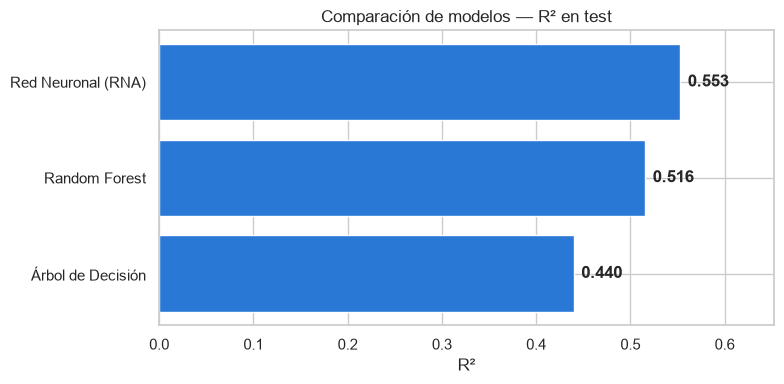

In [18]:
plt.figure(figsize=(8, 4))
orden = resultados.sort_values("R2")
plt.barh(orden["Modelo"], orden["R2"], color="#2a78d6")
for i, (modelo, r2) in enumerate(zip(orden["Modelo"], orden["R2"])):
    plt.text(r2 + 0.008, i, f"{r2:.3f}", va="center", fontweight="bold")
plt.title("Comparación de modelos — R² en test")
plt.xlabel("R²")
plt.xlim(0, max(orden["R2"]) * 1.18)
plt.tight_layout()
plt.show()

## 12. Predicción frente a valor real

Cada punto es un lote del conjunto de prueba. La diagonal roja marca la
predicción perfecta.

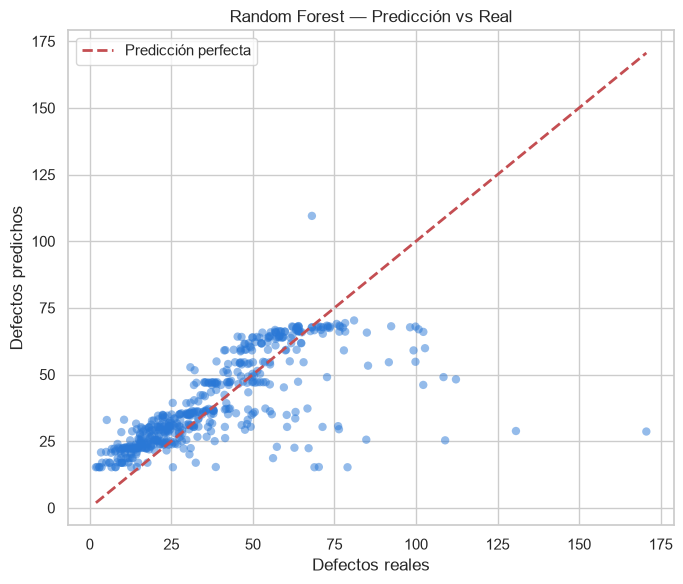

In [19]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, pred_rf, alpha=0.5, color="#2a78d6", edgecolor="none")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         "r--", lw=2, label="Predicción perfecta")
plt.xlabel("Defectos reales")
plt.ylabel("Defectos predichos")
plt.title("Random Forest — Predicción vs Real")
plt.legend()
plt.tight_layout()
plt.show()

> El modelo sigue bien la diagonal en el rango habitual (0–100 defectos), pero
> **subestima sistemáticamente los lotes extremos**: la nube se aplana por debajo
> de la diagonal a partir de ~150 defectos. Con solo cuatro sensores, los lotes
> catastróficos siguen siendo impredecibles — sus causas probablemente están
> fuera de lo medido (calidad de la materia prima, desgaste del molde, paradas
> de línea).

## 13. Aplicación a un caso nuevo

Se simula un lote no visto con **vibración alta** (6.3, cerca del máximo
observado de 6.5) para comprobar que el modelo reacciona como debería.

In [20]:
nuevo = pd.DataFrame([{
    "Temp_Matriz_C": 238.0,
    "Presion_Inyeccion_Bar": 178.0,
    "Tiempo_Ciclo_s": 8.5,
    "Vibracion_RMS": 6.3,
}])

estimado = modelo_rf.predict(nuevo)[0]
mediana = datos["Defectos_Lote"].median()

print(nuevo.to_string(index=False), "\n")
print(f"Defectos estimados : {estimado:.2f}")
print(f"Mediana histórica  : {mediana:.2f}")
print(f"Razón              : {estimado / mediana:.2f}x la mediana")

 Temp_Matriz_C  Presion_Inyeccion_Bar  Tiempo_Ciclo_s  Vibracion_RMS
      238.0000               178.0000          8.5000         6.3000 

Defectos estimados : 69.53
Mediana histórica  : 34.88
Razón              : 1.99x la mediana


> Frente a una mediana histórica de ~35 defectos, el modelo estima
> aproximadamente **el doble** para este lote, coherente con una vibración cercana
> al máximo observado. El comportamiento del modelo es consistente con el
> hallazgo de la sección 8.

---

## Conclusiones

1. **La vibración RMS es el predictor dominante**, con cerca del 89 % de la
   importancia del modelo. Es la variable que MetalX debería instrumentar y
   vigilar de forma prioritaria.

2. **La red neuronal obtiene el mejor R²**, seguida de cerca por Random Forest.
   La diferencia es pequeña, y **Random Forest es preferible en la práctica**:
   entrena en segundos, no requiere ajuste de épocas y entrega importancia de
   variables interpretable — algo que la red no ofrece.

3. **El techo de R² ≈ 0.55 es estructural, no un defecto del modelado.** Se
   explica por dos razones combinadas: solo una de las cuatro variables aporta
   señal real, y la cola larga de la variable objetivo (*skewness* 4.65) es
   inalcanzable con los sensores disponibles.

### Qué haría falta para mejorarlo

| Vía | Descripción |
|---|---|
| **Transformar el objetivo** | Aplicar `log1p` a `Defectos_Lote` para comprimir la cola y estabilizar la varianza |
| **Ampliar los datos** | Incorporar variables de materia prima, desgaste de molde y registros de mantenimiento |
| **Reformular el problema** | Pasar de regresión a **clasificación** (lote conforme / lote en riesgo), que es la decisión que realmente toma un supervisor de planta |